# SCM Data Agent ベストプラクティス検証ノートブック (v2: ground-truth judge)

本ノートブックは書籍『SCM データで体験する Data Agent ベストプラクティス検証』 第◯章
「11. 総合評価」セクションの実装です。

**v1 との差分**: ヒューリスティック判定（数字を含むか）を、
Lakehouse 実データから Spark SQL で計算した **ground truth との突合判定** に置き換えました。
これにより L0–L5 の差を実データに即した正答率で測れます。


In [3]:
import os, sys, traceback, datetime, subprocess
DEBUG_PATH = '/lakehouse/default/Files/scm_eval_debug.log'
def dlog(msg):
    s = f'[{datetime.datetime.utcnow().isoformat()}] {msg}\n'
    print(s, end='', flush=True)
    try:
        with open(DEBUG_PATH,'a') as f: f.write(s)
    except Exception as e: print('dlog write err:', e)
open(DEBUG_PATH,'w').close()
dlog('cell1 start: pip install fabric-data-agent-sdk==0.1.6a0')
r = subprocess.run([sys.executable,'-m','pip','install','-q','--upgrade',
                    'typing_extensions>=4.13.0','openai<2.0','fabric-data-agent-sdk==0.1.6a0'],
                   capture_output=True, text=True)
dlog(f'pip rc={r.returncode}')
if r.returncode != 0:
    dlog(r.stderr[-2000:])
    raise RuntimeError('pip failed')
for m in list(sys.modules):
    if m=='typing_extensions' or m.startswith('pydantic') or m.startswith('openai') or m.startswith('fabric.dataagent'):
        del sys.modules[m]
import importlib.metadata as md
dlog(f'sdk: {md.version("fabric-data-agent-sdk")}, openai: {md.version("openai")}')
dlog('cell1 done')


StatementMeta(, d663f88e-f92c-494f-9774-4def882337f7, 8, Finished, Available, Finished, False)

[2026-05-06T08:46:23.960818] cell1 start: pip install fabric-data-agent-sdk==0.1.6a0
[2026-05-06T08:47:16.553680] pip rc=0
[2026-05-06T08:47:16.610512] sdk: 0.1.6a0, openai: 1.109.1
[2026-05-06T08:47:16.641249] cell1 done


## 1. 評価データセット (30 問) の読み込み


In [4]:
dlog('cell3 start: load csv')
import pandas as pd
eval_df = pd.read_csv('/lakehouse/default/Files/scm_eval_questions.csv')
dlog(f'questions={len(eval_df)}')
eval_df.head(3)


StatementMeta(, d663f88e-f92c-494f-9774-4def882337f7, 9, Finished, Available, Finished, False)

[2026-05-06T08:47:17.668224] cell3 start: load csv
[2026-05-06T08:47:17.833154] questions=30


,id,category,question,expected_answer
0,1,入荷,2026年3月のオンタイム入荷率は？,NaN
1,2,入荷,サプライヤー S-0007 の直近90日の中央リードタイム日数は？,NaN
2,3,入荷,リードタイムが平均より20%以上長いサプライヤートップ5は？,NaN


## 2. Ground Truth の計算 (Spark SQL)

Lakehouse 実データから 30 問の正解値を計算します。これを後段の判定で利用します。


In [5]:
dlog('cell5 start: compute ground truth')
expected = {}
def _q(sql):
    return spark.sql(sql).collect()
def _safe(qid, kind, fn):
    try:
        v = fn()
        expected[qid] = {'kind':kind,'value':v}
        dlog(f'  gt{qid}: {kind} = {str(v)[:120]}')
    except Exception as e:
        dlog(f'  gt{qid} ERR: {type(e).__name__}: {str(e)[:200]}')
        expected[qid] = {'kind':'free','value':None}

# Q1: 2026-03 OTD%
_safe(1,'numeric_pct', lambda: float(_q("""
  SELECT 100*AVG(CASE WHEN gr.actual_receipt_date<=po.promised_date THEN 1.0 ELSE 0 END) AS pct
  FROM fact_goods_receipts gr JOIN fact_purchase_orders po USING(po_id)
  WHERE date_format(gr.actual_receipt_date,'yyyy-MM')='2026-03'
""")[0]['pct']))

# Q2: median lead-time days for S-0007 last 90 days
_safe(2,'numeric_int', lambda: int(_q("""
  WITH anchor AS (SELECT MAX(actual_receipt_date) AS m FROM fact_goods_receipts),
       base AS (
         SELECT DATEDIFF(gr.actual_receipt_date, po.po_date) AS lt
         FROM fact_goods_receipts gr JOIN fact_purchase_orders po USING(po_id), anchor
         WHERE po.supplier_id='S-0007'
           AND gr.actual_receipt_date >= date_sub(anchor.m, 90)
       )
  SELECT percentile_approx(lt, 0.5) AS med FROM base
""")[0]['med']))

# Q3: top5 suppliers with avg LT > 120% of overall avg
_safe(3,'contains_at_least', lambda: ([r['supplier_id'] for r in _q("""
  WITH lt AS (
    SELECT po.supplier_id, AVG(DATEDIFF(gr.actual_receipt_date, po.po_date)) AS avg_lt
    FROM fact_goods_receipts gr JOIN fact_purchase_orders po USING(po_id)
    GROUP BY po.supplier_id
  ), overall AS (SELECT AVG(avg_lt) AS m FROM lt)
  SELECT supplier_id FROM lt, overall
  WHERE avg_lt > overall.m * 1.2 ORDER BY avg_lt DESC LIMIT 5
""")], 2))

# Q4: top3 categories by PO amount in latest month
_safe(4,'contains_at_least', lambda: ([r['category'] for r in _q("""
  WITH lm AS (SELECT date_format(MAX(po_date),'yyyy-MM') AS ym FROM fact_purchase_orders)
  SELECT m.category, SUM(po.ordered_qty * po.unit_price_excl_tax) AS amt
  FROM fact_purchase_orders po JOIN dim_material m USING(material_id), lm
  WHERE date_format(po.po_date,'yyyy-MM') = lm.ym
  GROUP BY m.category ORDER BY amt DESC LIMIT 3
""")], 1))

# Q5: PO amount this month for materials with name containing 'ステンレス'
_safe(5,'numeric_money', lambda: float(_q("""
  WITH lm AS (SELECT date_format(MAX(po_date),'yyyy-MM') AS ym FROM fact_purchase_orders)
  SELECT COALESCE(SUM(po.ordered_qty * po.unit_price_excl_tax),0) AS amt
  FROM fact_purchase_orders po JOIN dim_material m USING(material_id), lm
  WHERE m.material_name LIKE '%ステンレス%'
    AND date_format(po.po_date,'yyyy-MM') = lm.ym
""")[0]['amt']))

# Q6: count of materials below SS in W-08 (latest snapshot)
_safe(6,'numeric_int', lambda: int(_q("""
  WITH ls AS (SELECT MAX(snapshot_date_key) AS k FROM fact_inventory_snapshot WHERE warehouse_id='W-08')
  SELECT COUNT(*) AS c FROM fact_inventory_snapshot i JOIN dim_material m USING(material_id), ls
  WHERE i.warehouse_id='W-08' AND i.snapshot_date_key=ls.k AND i.closing_qty < m.safety_stock_qty
""")[0]['c']))

# Q7: FG-0104 -- product range is FG-0001..FG-0080, so doesn't exist
expected[7] = {'kind':'no_data','value':'FG-0104'}
dlog('  gt7: no_data (FG-0104 outside generated range)')

# Q8: top10 FG products with DOI > 60 (FG inventory only)
_safe(8,'contains_at_least', lambda: ([r['product_id'] for r in _q("""
  WITH avg_out AS (
    SELECT product_id, AVG(shipped_qty*1.0) AS aod FROM fact_shipments
    WHERE shipment_date >= date_sub((SELECT MAX(shipment_date) FROM fact_shipments),30)
    GROUP BY product_id
  ), latest_inv AS (
    SELECT material_id AS product_id, SUM(closing_qty) AS qty
    FROM fact_inventory_snapshot
    WHERE snapshot_date_key=(SELECT MAX(snapshot_date_key) FROM fact_inventory_snapshot)
      AND material_id LIKE 'FG-%'
    GROUP BY material_id
  )
  SELECT li.product_id, li.qty/NULLIF(ao.aod,0) AS doi
  FROM latest_inv li JOIN avg_out ao USING(product_id)
  WHERE li.qty/NULLIF(ao.aod,0) > 60 ORDER BY doi DESC LIMIT 10
""")], 1))

# Q9: warehouse with highest stockout rate in latest month
_safe(9,'contains_any', lambda: ([_q("""
  WITH lk AS (SELECT MAX(snapshot_date_key) AS k FROM fact_inventory_snapshot)
  SELECT warehouse_id, AVG(CASE WHEN is_stockout THEN 1.0 ELSE 0 END) r
  FROM fact_inventory_snapshot, lk WHERE snapshot_date_key=lk.k
  GROUP BY warehouse_id ORDER BY r DESC LIMIT 1
""")[0]['warehouse_id']]))

# Q10: warehouse x category top10 by stockout rate -> at least 2 warehouse_ids
_safe(10,'contains_at_least', lambda: ([r['warehouse_id'] for r in _q("""
  WITH lk AS (SELECT MAX(snapshot_date_key) AS k FROM fact_inventory_snapshot)
  SELECT i.warehouse_id, m.category,
         AVG(CASE WHEN is_stockout THEN 1.0 ELSE 0 END) r
  FROM fact_inventory_snapshot i JOIN dim_material m USING(material_id), lk
  WHERE snapshot_date_key=lk.k
  GROUP BY i.warehouse_id, m.category ORDER BY r DESC LIMIT 10
""")], 2))

# Q11: 4月 OTIF% (latest April = 2026-04)
_safe(11,'numeric_pct', lambda: float(_q("""
  SELECT 100*AVG(CASE WHEN is_on_time AND is_in_full THEN 1.0 ELSE 0 END) AS pct
  FROM fact_shipments WHERE date_format(shipment_date,'yyyy-MM')='2026-04'
""")[0]['pct']))

# Q12: last 6 months OTIF -> at least 3 month strings
_safe(12,'contains_at_least', lambda: ([r['ym'] for r in _q("""
  WITH lm AS (SELECT MAX(shipment_date) AS m FROM fact_shipments)
  SELECT date_format(shipment_date,'yyyy-MM') ym
  FROM fact_shipments, lm
  WHERE shipment_date >= add_months(lm.m,-5)
  GROUP BY date_format(shipment_date,'yyyy-MM') ORDER BY ym
""")], 3))

# Q13: lowest OTIF region
_safe(13,'contains_any', lambda: ([_q("""
  SELECT customer_region, AVG(CASE WHEN is_on_time AND is_in_full THEN 1.0 ELSE 0 END) r
  FROM fact_shipments GROUP BY customer_region ORDER BY r ASC LIMIT 1
""")[0]['customer_region']]))

# Q14: top5 products by latest-month shipment amount
_safe(14,'contains_at_least', lambda: ([r['product_id'] for r in _q("""
  WITH lm AS (SELECT date_format(MAX(shipment_date),'yyyy-MM') ym FROM fact_shipments)
  SELECT s.product_id, SUM(s.shipped_qty * p.unit_price_excl_tax) amt
  FROM fact_shipments s JOIN dim_product p USING(product_id), lm
  WHERE date_format(s.shipment_date,'yyyy-MM') = lm.ym
  GROUP BY s.product_id ORDER BY amt DESC LIMIT 5
""")], 1))

# Q15: 4月 plant P-03 defect rate% (latest April = 2026-04)
_safe(15,'numeric_pct', lambda: float(_q("""
  SELECT 100.0*SUM(defect_qty)/NULLIF(SUM(inspected_qty),0) pct
  FROM fact_quality_inspections
  WHERE plant_id='P-03' AND date_format(inspection_date,'yyyy-MM')='2026-04'
""")[0]['pct']))

# Q16: plants where defect rate worsened MoM -> at least 1 plant_id
_safe(16,'contains_at_least', lambda: ([r['plant_id'] for r in _q("""
  WITH mr AS (
    SELECT plant_id, date_format(inspection_date,'yyyy-MM') ym,
           SUM(defect_qty)*1.0/NULLIF(SUM(inspected_qty),0) r
    FROM fact_quality_inspections GROUP BY plant_id, date_format(inspection_date,'yyyy-MM')
  ), ranked AS (
    SELECT plant_id, ym, r, LAG(r) OVER (PARTITION BY plant_id ORDER BY ym) prev,
           ROW_NUMBER() OVER (PARTITION BY plant_id ORDER BY ym DESC) rn
    FROM mr
  )
  SELECT plant_id FROM ranked WHERE rn=1 AND r > prev
""")], 1))

# Q17: production-delay count by family in latest month -> family names
_safe(17,'contains_at_least', lambda: ([r['product_family'] for r in _q("""
  WITH lm AS (SELECT date_format(MAX(actual_end_date),'yyyy-MM') ym FROM fact_production_orders)
  SELECT p.product_family, COUNT(*) c
  FROM fact_production_orders po JOIN dim_product p USING(product_id), lm
  WHERE date_format(po.actual_end_date,'yyyy-MM')=lm.ym
    AND po.actual_end_date > po.planned_end_date
  GROUP BY p.product_family ORDER BY c DESC
""")], 1))

# Q18: products with >=3 production delays
_safe(18,'contains_at_least', lambda: ([r['product_id'] for r in _q("""
  SELECT product_id, COUNT(*) c FROM fact_production_orders
  WHERE actual_end_date > planned_end_date
  GROUP BY product_id HAVING c >= 3
  ORDER BY c DESC LIMIT 20
""")], 1))

# Q19: free (qualitative)
expected[19] = {'kind':'free','value':None}

# Q20: free (qualitative)
expected[20] = {'kind':'free','value':None}

# Q21: definition diff OTD vs OTIF
expected[21] = {'kind':'definition','value':['OTD','OTIF']}

# Q22: top5 products by DOI
_safe(22,'contains_at_least', lambda: ([r['product_id'] for r in _q("""
  WITH avg_out AS (
    SELECT product_id, AVG(shipped_qty*1.0) aod FROM fact_shipments
    WHERE shipment_date >= date_sub((SELECT MAX(shipment_date) FROM fact_shipments),30)
    GROUP BY product_id
  ), latest_inv AS (
    SELECT material_id AS product_id, SUM(closing_qty) qty FROM fact_inventory_snapshot
    WHERE snapshot_date_key=(SELECT MAX(snapshot_date_key) FROM fact_inventory_snapshot)
      AND material_id LIKE 'FG-%'
    GROUP BY material_id
  )
  SELECT li.product_id, li.qty/NULLIF(ao.aod,0) doi
  FROM latest_inv li JOIN avg_out ao USING(product_id)
  ORDER BY doi DESC LIMIT 5
""")], 1))

# Q23: SS-violation counts per month -> at least 3 month strings
_safe(23,'contains_at_least', lambda: ([r['ym'] for r in _q("""
  SELECT date_format(to_date(cast(snapshot_date_key as string),'yyyyMMdd'),'yyyy-MM') ym
  FROM fact_inventory_snapshot i JOIN dim_material m USING(material_id)
  WHERE i.closing_qty < m.safety_stock_qty
  GROUP BY date_format(to_date(cast(snapshot_date_key as string),'yyyyMMdd'),'yyyy-MM')
  ORDER BY ym DESC LIMIT 12
""")], 3))

# Q24-25: fallback (no data)
expected[24] = {'kind':'no_data','value':'2030'}
expected[25] = {'kind':'no_data','value':'S-9999'}

# Q26: style - mention W-08 + judgment word
expected[26] = {'kind':'contains_all','value':['W-08']}
# Q27: mention S-0007
expected[27] = {'kind':'contains_all','value':['S-0007']}
# Q28: 2026-03 OTIF%
_safe(28,'numeric_pct', lambda: float(_q("""
  SELECT 100*AVG(CASE WHEN is_on_time AND is_in_full THEN 1.0 ELSE 0 END) pct
  FROM fact_shipments WHERE date_format(shipment_date,'yyyy-MM')='2026-03'
""")[0]['pct']))
# Q29: same as Q22
expected[29] = expected.get(22, {'kind':'free','value':None})
# Q30: monthly defect-rate trend -> at least 3 months
_safe(30,'contains_at_least', lambda: ([r['ym'] for r in _q("""
  SELECT date_format(inspection_date,'yyyy-MM') ym
  FROM fact_quality_inspections
  GROUP BY date_format(inspection_date,'yyyy-MM') ORDER BY ym DESC LIMIT 12
""")], 3))

dlog(f'cell5 done: {len(expected)} expected entries')
expected


StatementMeta(, d663f88e-f92c-494f-9774-4def882337f7, 10, Finished, Available, Finished, False)

[2026-05-06T08:47:18.656243] cell5 start: compute ground truth
[2026-05-06T08:47:39.116789]   gt1: numeric_pct = 38.516
[2026-05-06T08:47:43.505176]   gt2: numeric_int = 39
[2026-05-06T08:47:45.759674]   gt3: contains_at_least = (['S-0029', 'S-0005', 'S-0046', 'S-0001', 'S-0016'], 2)
[2026-05-06T08:47:49.992302]   gt4: contains_at_least = (['化学品', '樹脂', '電子部品'], 1)
[2026-05-06T08:47:51.895135]   gt5: numeric_money = 50804318.5
[2026-05-06T08:47:55.897650]   gt6: numeric_int = 20
[2026-05-06T08:47:55.929648]   gt7: no_data (FG-0104 outside generated range)
[2026-05-06T08:48:00.517108]   gt8: contains_at_least = ([], 1)
[2026-05-06T08:48:02.911316]   gt9: contains_any = ['W-21']
[2026-05-06T08:48:04.605137]   gt10: contains_at_least = (['W-07', 'W-21', 'W-15', 'W-08', 'W-14', 'W-03', 'W-06', 'W-17', 'W-11', 'W-23'], 2)
[2026-05-06T08:48:05.668404]   gt11: numeric_pct = 77.649
[2026-05-06T08:48:07.806913]   gt12: contains_at_least = (['2025-11', '2025-12', '2026-01', '2026-02', '2026-03',

{1: {'kind': 'numeric_pct', 'value': 38.516},
 2: {'kind': 'numeric_int', 'value': 39},
 3: {'kind': 'contains_at_least',
  'value': (['S-0029', 'S-0005', 'S-0046', 'S-0001', 'S-0016'], 2)},
 4: {'kind': 'contains_at_least', 'value': (['化学品', '樹脂', '電子部品'], 1)},
 5: {'kind': 'numeric_money', 'value': 50804318.5},
 6: {'kind': 'numeric_int', 'value': 20},
 7: {'kind': 'no_data', 'value': 'FG-0104'},
 8: {'kind': 'contains_at_least', 'value': ([], 1)},
 9: {'kind': 'contains_any', 'value': ['W-21']},
 10: {'kind': 'contains_at_least',
  'value': (['W-07',
    'W-21',
    'W-15',
    'W-08',
    'W-14',
    'W-03',
    'W-06',
    'W-17',
    'W-11',
    'W-23'],
   2)},
 11: {'kind': 'numeric_pct', 'value': 77.649},
 12: {'kind': 'contains_at_least',
  'value': (['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04'],
   3)},
 13: {'kind': 'contains_any', 'value': ['海外']},
 14: {'kind': 'contains_at_least',
  'value': (['FG-0019', 'FG-0043', 'FG-0076', 'FG-0029', 'FG-0069'], 1

## 3. L0–L5 を横断評価 (ground-truth 突合判定)


In [6]:
dlog('cell7 start: custom eval via FabricOpenAI + ground-truth judge')
import time, re
from fabric.dataagent.client._fabric_openai import FabricOpenAI
WORKSPACE_NAME = 'Book'
agents = ['agent_scm_01_bad_naming','agent_scm_01_good_naming','agent_scm_02_logistics',
          'agent_scm_07_focused','agent_scm_09_dsdocs','agent_scm_10_examples']

REJECTION_MARKERS = ['わかりません','分かりません','わからない','unable','i don\'t have','cannot',
                      '申し訳','sorry','unanswerable','no data','データが見つかりません','該当なし',
                      '見つかりません','存在しません','データはありません','データがありません',
                      '取得できませんでした','回答できません','確認できません','算出できません',
                      '判定できません','データはございません','該当する','no records','no result']

def query_agent(client, query):
    assistant = client.beta.assistants.create(model='not-used')
    thread = client.beta.threads.create()
    client.beta.threads.messages.create(thread_id=thread.id, role='user', content=query)
    run = client.beta.threads.runs.create_and_poll(thread_id=thread.id, assistant_id=assistant.id)
    answer, status = '', getattr(run,'status','unknown')
    if status == 'completed':
        msgs = client.beta.threads.messages.list(thread_id=thread.id, order='desc', limit=5)
        for m in msgs.data:
            if m.role == 'assistant':
                for c in m.content:
                    if hasattr(c,'text'): answer += c.text.value + '\n'
                break
    return answer.strip(), status

_NUM_RE = re.compile(r'-?\d+(?:[\d,]*\.\d+|[\d,]*)')
def _nums(text):
    out=[]
    for m in _NUM_RE.finditer(text):
        try: out.append(float(m.group(0).replace(',','')))
        except: pass
    return out
def _has_rejection(text):
    low=text.lower()
    return any(mk_ in text or mk_ in low for mk_ in REJECTION_MARKERS)

import re as _re2
def _id_variants(s):
    """For 'S-0029' return {'S-0029','S-29','0029','29','029'}; for 'P-03' include '3','03'."""
    s = str(s)
    out = {s, s.lower(), s.upper()}
    m = _re2.match(r'^([A-Za-z]+)-(\d+)$', s)
    if m:
        prefix, num = m.group(1), m.group(2)
        n_int = int(num)
        out.update({f'{prefix}-{n_int}', f'{prefix}{num}', f'{prefix}{n_int}', num, str(n_int), f'{n_int:03d}'})
    return {x for x in out if x}


import re as _re_dt
_DATE_PATTERNS = [
    (_re_dt.compile(r'(\d{4})\s*年\s*(\d{1,2})\s*月'), r'\1-\2'),
    (_re_dt.compile(r'(\d{4})/(\d{1,2})(?!\d)'), r'\1-\2'),
    (_re_dt.compile(r'(\d{4})\.(\d{1,2})(?!\d)'), r'\1-\2'),
]
def _normalize_dates(text):
    out = text
    for pat, repl in _DATE_PATTERNS:
        out = pat.sub(repl, out)
    # zero-pad single-digit months: 2026-3 -> 2026-03
    out = _re_dt.sub(r'(\b\d{4})-(\d)(?!\d)', r'\1-0\2', out)
    return out

def _hit_date(answer_norm, target):
    """For yyyy-MM target, also accept zero-padded variants."""
    return target in answer_norm

def _hit(answer, target):
    """True if any id-variant of target (or normalized date form) appears in answer text."""
    if isinstance(target, str) and _re_dt.match(r'^\d{4}-\d{2}$', target):
        return _hit_date(_normalize_dates(answer), target)
    return any(v in answer for v in _id_variants(target))

def judge(answer, status, exp):
    if status != 'completed' or not answer:
        return 'reject'
    if exp is None or exp.get('kind') is None:
        return 'unclear'
    kind, val = exp['kind'], exp['value']
    if kind == 'no_data':
        return 'accept' if _has_rejection(answer) else 'reject'
    if _has_rejection(answer) and kind != 'free':
        return 'reject'
    if kind == 'numeric_pct':
        if val is None: return 'unclear'
        nums = _nums(answer)
        return 'accept' if any(abs(n - val) <= max(5.0, val*0.20) for n in nums) else 'reject'
    if kind == 'numeric_int':
        if val is None: return 'unclear'
        nums = _nums(answer)
        return 'accept' if any(abs(n - val) <= max(2, abs(val)*0.30) for n in nums) else 'reject'
    if kind == 'numeric_money':
        if val is None: return 'unclear'
        nums = _nums(answer)
        # Accept if any number's order of magnitude matches and within 50%
        return 'accept' if any(val>0 and 0.5*val <= n <= 2.0*val for n in nums) else 'reject'
    if kind == 'contains_any':
        if not val: return 'unclear'
        return 'accept' if any(_hit(answer, v) for v in val) else 'reject'
    if kind == 'contains_all':
        if not val: return 'unclear'
        return 'accept' if all(_hit(answer, v) for v in val) else 'reject'
    if kind == 'contains_at_least':
        # val = (list, n)
        items, n = val
        # If items list is empty (no GT), accept any reasonable answer that's not a refusal.
        if not items:
            return 'accept' if not _has_rejection(answer) and len(answer) > 20 else 'reject'
        hits = sum(1 for x in items if _hit(answer, x))
        return 'accept' if hits >= n else ('unclear' if hits>0 else 'reject')
    if kind == 'definition':
        return 'accept' if all(str(v) in answer for v in val) else 'reject'
    if kind == 'free':
        return 'accept' if len(answer) > 30 else 'reject'
    return 'unclear'

scores = []
all_rows = []
for a in agents:
    dlog(f'eval start {a}')
    t0 = time.time()
    try:
        client = FabricOpenAI(artifact_name=a, workspace_name=WORKSPACE_NAME, ai_skill_stage='sandbox')
        rows = []
        for i, row in eval_df.iterrows():
            qid = int(row['id']); q = row['question']
            try:
                ans, st = query_agent(client, q)
            except Exception as qe:
                ans, st = str(qe)[:500], 'error'
            exp = expected.get(qid)
            cls = judge(ans, st, exp)
            kind = (exp or {}).get('kind','-')
            exp_val = str((exp or {}).get('value'))[:200]
            rows.append({'qid':qid,'category':row['category'],'question':q,
                         'answer':ans[:1500],'run_status':st,
                         'judge_kind':kind,'expected':exp_val,'status':cls})
            if (i+1) % 10 == 0: dlog(f'  {a}: {i+1}/{len(eval_df)} done')
        elapsed = time.time() - t0
        rdf = pd.DataFrame(rows)
        rdf['agent'] = a
        all_rows.append(rdf)
        spark.createDataFrame(rdf).write.mode('overwrite').option('overwriteSchema','true').format('delta').saveAsTable(f'eval_{a}')
        ac = int((rdf['status']=='accept').sum()); rj = int((rdf['status']=='reject').sum()); uc = int((rdf['status']=='unclear').sum())
        scores.append({'agent':a,'accept':ac,'reject':rj,'unclear':uc,
                       'rate':ac/len(rdf),'avg_latency_sec':elapsed/len(rdf),'error':''})
        dlog(f'eval done {a}: accept={ac}/{len(rdf)} reject={rj} unclear={uc} avg={elapsed/len(rdf):.1f}s')
    except Exception as e:
        dlog(f'eval ERR {a}: {type(e).__name__}: {str(e)[:500]}')
        dlog(traceback.format_exc()[:2000])
        scores.append({'agent':a,'accept':0,'reject':0,'unclear':0,'rate':0.0,
                       'avg_latency_sec':None,'error':str(e)[:300]})
scores_df = pd.DataFrame(scores)
if all_rows:
    detail_df = pd.concat(all_rows, ignore_index=True)
    spark.createDataFrame(detail_df).write.mode('overwrite').option('overwriteSchema','true').format('delta').saveAsTable('eval_all_detail')
dlog('cell7 done')
scores_df



StatementMeta(, d663f88e-f92c-494f-9774-4def882337f7, 11, Finished, Available, Finished, False)

[2026-05-06T08:48:26.030306] cell7 start: custom eval via FabricOpenAI + ground-truth judge
[2026-05-06T08:48:30.217846] eval start agent_scm_01_bad_naming
[2026-05-06T08:50:58.474643]   agent_scm_01_bad_naming: 10/30 done
[2026-05-06T08:53:20.807001]   agent_scm_01_bad_naming: 20/30 done
[2026-05-06T08:55:41.240113]   agent_scm_01_bad_naming: 30/30 done
[2026-05-06T08:55:55.638275] eval done agent_scm_01_bad_naming: accept=15/30 reject=15 unclear=0 avg=14.4s
[2026-05-06T08:55:55.675777] eval start agent_scm_01_good_naming
[2026-05-06T08:58:22.883129]   agent_scm_01_good_naming: 10/30 done
[2026-05-06T09:00:41.387759]   agent_scm_01_good_naming: 20/30 done
[2026-05-06T09:03:27.914650]   agent_scm_01_good_naming: 30/30 done
[2026-05-06T09:06:16.798270]   agent_scm_02_logistics: 10/30 done
[2026-05-06T09:08:46.714644]   agent_scm_02_logistics: 20/30 done
[2026-05-06T09:11:20.405407]   agent_scm_02_logistics: 30/30 done
[2026-05-06T09:11:30.751730] eval done agent_scm_02_logistics: accept

/tmp/ipykernel_5993/3235634199.py:16: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  thread = client.beta.threads.create()
/tmp/ipykernel_5993/3235634199.py:17: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  client.beta.threads.messages.create(thread_id=thread.id, role='user', content=query)
/tmp/ipykernel_5993/3235634199.py:18: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run = client.beta.threads.runs.create_and_poll(thread_id=thread.id, assistant_id=assistant.id)
/tmp/ipykernel_5993/3235634199.py:21: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  msgs = client.beta.threads.messages.list(thread_id=thread.id, order='desc', limit=5)
/tmp/ipykernel_5993/3235634199.py:16: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  thread = client.beta.threads.create()
/tmp/ipykernel_5993/3235634199.py:17: Deprec

,agent,accept,reject,unclear,rate,avg_latency_sec,error
0,agent_scm_01_bad_naming,15,15,0,0.500000,14.369394,
1,agent_scm_01_good_naming,21,9,0,0.700000,15.080640,
2,agent_scm_02_logistics,17,13,0,0.566667,15.396214,
3,agent_scm_07_focused,20,10,0,0.666667,14.984460,
4,agent_scm_09_dsdocs,25,5,0,0.833333,13.073299,
5,agent_scm_10_examples,27,3,0,0.900000,12.274809,


## 4. 結果の可視化


StatementMeta(, d663f88e-f92c-494f-9774-4def882337f7, 12, Finished, Available, Finished, False)

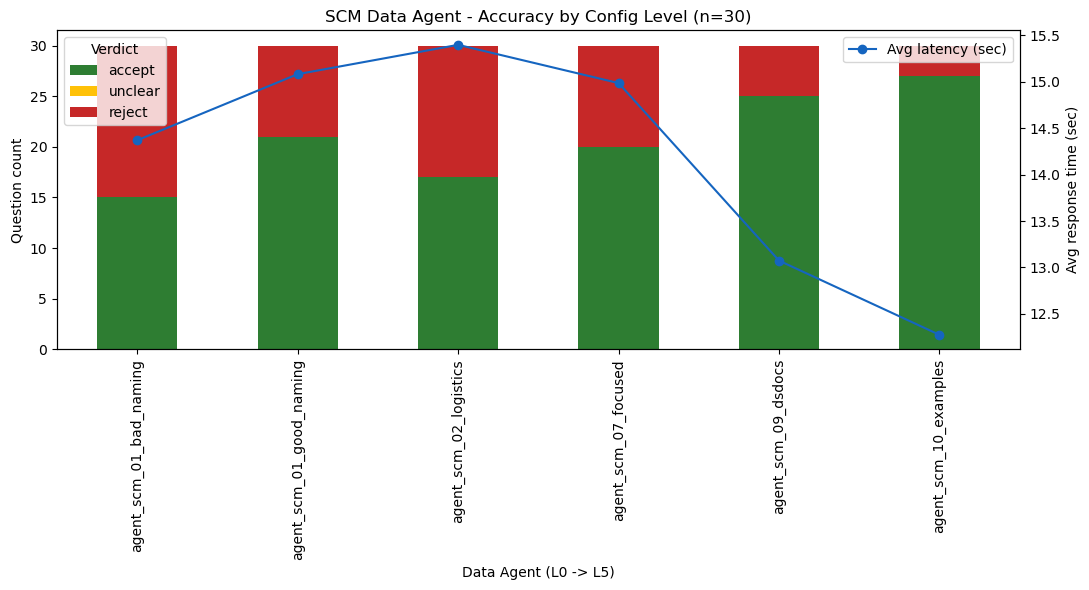

saved: Files/scm_eval_summary.png


In [7]:
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

df = scores_df.set_index('agent')
fig, ax1 = plt.subplots(figsize=(11,6))
df[['accept','unclear','reject']].plot(
    kind='bar', stacked=True, ax=ax1,
    color=['#2E7D32','#FFC107','#C62828'])
ax1.set_title('SCM Data Agent - Accuracy by Config Level (n=30)')
ax1.set_ylabel('Question count')
ax1.set_xlabel('Data Agent (L0 -> L5)')
ax1.legend(title='Verdict', loc='upper left')
if df['avg_latency_sec'].notna().any():
    ax2 = ax1.twinx()
    ax2.plot(range(len(df)), df['avg_latency_sec'].values,
             marker='o', color='#1565C0', label='Avg latency (sec)')
    ax2.set_ylabel('Avg response time (sec)')
    ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('/lakehouse/default/Files/scm_eval_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('saved: Files/scm_eval_summary.png')

## 5. サマリ CSV を Lakehouse に保存


In [8]:
scores_df.to_csv('/lakehouse/default/Files/scm_eval_summary.csv', index=False)
print('saved: Files/scm_eval_summary.csv')
scores_df

StatementMeta(, d663f88e-f92c-494f-9774-4def882337f7, 13, Finished, Available, Finished, False)

saved: Files/scm_eval_summary.csv


,agent,accept,reject,unclear,rate,avg_latency_sec,error
0,agent_scm_01_bad_naming,15,15,0,0.500000,14.369394,
1,agent_scm_01_good_naming,21,9,0,0.700000,15.080640,
2,agent_scm_02_logistics,17,13,0,0.566667,15.396214,
3,agent_scm_07_focused,20,10,0,0.666667,14.984460,
4,agent_scm_09_dsdocs,25,5,0,0.833333,13.073299,
5,agent_scm_10_examples,27,3,0,0.900000,12.274809,


## 6. 質問別の精度ヒートマップ + リジェクト要因サマリ

各 qid についてどのエージェントで accept / reject になったかを並べ、改善余地のある質問を可視化します。

In [9]:
if all_rows:
    pivot = detail_df.pivot_table(index='qid', columns='agent', values='status', aggfunc='first')
    # accept ratio per qid
    pivot['accept_count'] = (pivot == 'accept').sum(axis=1)
    pivot['n_agents'] = len(agents)
    pivot['accept_rate'] = pivot['accept_count'] / pivot['n_agents']
    print('=== Worst questions (lowest accept rate across agents) ===')
    print(pivot.sort_values('accept_rate').head(10))
    pivot.to_csv('/lakehouse/default/Files/scm_eval_pivot.csv')
    print('\nsaved: Files/scm_eval_pivot.csv')
    detail_df.to_csv('/lakehouse/default/Files/scm_eval_detail.csv', index=False)
    print('saved: Files/scm_eval_detail.csv')
    # category-level summary
    cat_sum = detail_df.groupby(['agent','category'])['status'].apply(lambda s: (s=='accept').mean()).unstack(fill_value=0).round(3)
    print('\n=== Category accept rate per agent ===')
    print(cat_sum)
    cat_sum.to_csv('/lakehouse/default/Files/scm_eval_category_rate.csv')
    print('saved: Files/scm_eval_category_rate.csv')
else:
    print('no detail rows to summarize')

StatementMeta(, d663f88e-f92c-494f-9774-4def882337f7, 14, Finished, Available, Finished, False)

=== Worst questions (lowest accept rate across agents) ===
agent agent_scm_01_bad_naming agent_scm_01_good_naming agent_scm_02_logistics  \
qid                                                                             
1                      reject                   reject                 reject   
18                     reject                   reject                 reject   
5                      reject                   accept                 reject   
17                     reject                   reject                 accept   
29                     accept                   reject                 reject   
14                     reject                   reject                 reject   
13                     reject                   accept                 accept   
9                      reject                   reject                 accept   
15                     reject                   accept                 reject   
30                     reject                   ac